### RaschPy SLM worked example

This notebook works through a sample Rasch analysis of a simulated data set (1,000 persons, 20 items, 40% missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.SLM_Sim(no_of_items=10, no_of_persons=40, item_range=2, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
responses_disconnected.iloc[:20, 5:] = float('nan')   # first 20 persons: only answer items 1-5
responses_disconnected.iloc[20:, :5] = float('nan')   # last 20 persons: only answer items 6-10

broken_slm = rp.SLM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/slm.py:169: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 5): ['Item_1', 'Item_2', 'Item_3', 'Item_4', 'Item_5']; Sub-group 2 (size 5): ['Item_6', 'Item_7', 'Item_8', 'Item_9', 'Item_10']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_19882/2314929751.py:6: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_slm = rp.SLM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_slm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4', 'Item_5'],
  ['Item_6', 'Item_7', 'Item_8', 'Item_9', 'Item_10']],
 'directionally_isolated_items': [],
 'strongly_connected': False}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=999` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set. 50 items, 1,000 persons, 40% missing data (so each person responds to ~30 items and each item has ~600 responses).

In [4]:
sim = rp.SLM_Sim(no_of_items=50, no_of_persons=1000, missing=0.4, seed=999)
sim.responses.to_csv('slm_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_slm()` to load and validate it — it coerces values to 0/1 and flags anything else as missing. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_slm('slm_scores.csv')

Check the data - view the first two lines

In [6]:
data.head(2)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,...,Item_41,Item_42,Item_43,Item_44,Item_45,Item_46,Item_47,Item_48,Item_49,Item_50
Person_1,NaN,1.0,0.0,NaN,1.0,NaN,NaN,NaN,1.0,NaN,...,1.0,1.0,1.0,1.0,1.0,NaN,1.0,0.0,NaN,1.0
Person_2,0.0,1.0,0.0,NaN,1.0,NaN,NaN,NaN,1.0,0.0,...,0.0,0.0,1.0,NaN,0.0,0.0,0.0,NaN,0.0,NaN


Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,...,Item_41,Item_42,Item_43,Item_44,Item_45,Item_46,Item_47,Item_48,Item_49,Item_50


Create an SLM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `slm.generating`, which lets us check parameter recovery further down. If you are using your own data, pass a DataFrame (e.g. `rp.SLM(data)`) instead.

In [8]:
slm = rp.SLM(sim)

Generate item estimates. The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
slm.calibrate()

CPU times: user 2.46 ms, sys: 1.48 ms, total: 3.94 ms
Wall time: 2.96 ms


Check the item location estimates - view the first two items

In [10]:
slm.items.head(2)

Item_1    0.393557
Item_2   -1.007203
dtype: float64

Since this is simulated data, we know the true generating item locations (`slm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

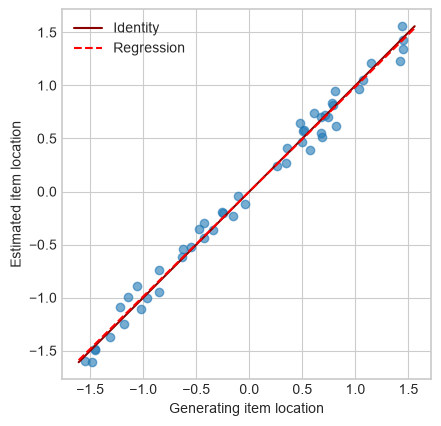

item location Pearson correlation:               0.994
item location SD ratio (estimated / generating): 0.994
item location regression coefficient:            0.988
item location RMSE:                              0.097


In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:               {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')

recovery_plot(slm.generating.items, slm.items, 'item location', 'my_slm_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [12]:
%%time
slm.item_stats_df(full=True)
slm.item_stats.to_csv('slm_item_stats.csv')

CPU times: user 1.93 s, sys: 138 ms, total: 2.06 s
Wall time: 2.06 s


Check the item statistics table - view the first ten items with `.head(10)`

In [13]:
slm.item_stats.head(10)

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Item_1,0.394,0.097,0.216,0.594,591,0.430,1.048,1.078,1.049,0.665,0.908,0.491,0.520
Item_2,-1.007,0.107,-1.212,-0.794,608,0.668,0.954,-0.955,0.993,-0.049,1.054,0.514,0.499
Item_3,0.839,0.107,0.628,1.066,587,0.358,0.957,-0.925,0.992,-0.065,1.065,0.519,0.498
Item_4,1.226,0.106,1.025,1.444,618,0.293,1.033,0.649,0.999,0.031,0.965,0.475,0.495
Item_5,-1.602,0.121,-1.870,-1.371,602,0.769,0.958,-0.702,1.089,0.685,1.022,0.454,0.467
Item_6,0.576,0.100,0.370,0.768,601,0.398,0.947,-1.195,0.939,-0.754,1.091,0.542,0.514
Item_7,-0.997,0.101,-1.217,-0.821,595,0.677,0.941,-1.212,0.895,-1.096,1.103,0.531,0.492
Item_8,0.242,0.096,0.066,0.428,606,0.457,1.042,0.984,1.113,1.547,0.895,0.493,0.525
Item_9,-0.621,0.103,-0.802,-0.399,598,0.617,0.983,-0.355,0.959,-0.479,1.035,0.523,0.515
Item_10,-0.195,0.099,-0.392,-0.009,599,0.546,0.983,-0.396,1.046,0.648,1.011,0.522,0.519


Generate a table of person statistics (and check run time), and save to file

In [14]:
%%time
slm.person_stats_df(full=True)
slm.person_stats.to_csv('slm_person_stats.csv')

CPU times: user 9.95 ms, sys: 2.17 ms, total: 12.1 ms
Wall time: 10.8 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [15]:
slm.person_stats.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Infit Z,Outfit MS,Outfit Z
Person_1,0.981,0.400,0.378,24,34,0.706,0.891,-0.617,0.766,-0.844
Person_2,-0.691,0.424,0.432,10,29,0.345,1.037,0.260,0.978,-0.012
Person_3,-3.101,0.855,0.651,1,27,0.037,0.580,-0.489,0.221,-0.773
Person_4,-0.553,0.424,0.383,11,28,0.393,0.814,-1.061,0.776,-1.070
Person_5,0.596,0.412,0.443,18,29,0.621,1.157,1.037,1.307,1.356
Person_6,-0.963,0.432,0.445,9,30,0.300,1.063,0.379,1.381,1.282
Person_7,-0.486,0.379,0.372,14,34,0.412,0.965,-0.195,0.912,-0.438
Person_8,-0.828,0.415,0.416,10,30,0.333,1.001,0.066,1.130,0.623
Person_9,0.294,0.421,0.494,16,28,0.571,1.378,2.071,1.467,1.997
Person_10,-2.183,0.538,0.493,4,34,0.118,0.839,-0.367,0.765,-0.242


And the same recovery check for person locations, against `slm.generating.persons`:

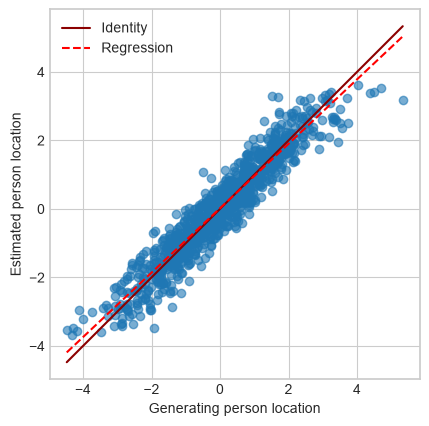

person location Pearson correlation:               0.95
person location SD ratio (estimated / generating): 0.991
person location regression coefficient:            0.941
person location RMSE:                              0.468


In [16]:
recovery_plot(slm.generating.persons, slm.persons, 'person location', 'my_slm_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [17]:
%%time
slm.test_stats_df()
slm.test_stats.to_csv('slm_test_stats.csv')

CPU times: user 1.34 ms, sys: 1 ms, total: 2.34 ms
Wall time: 1.57 ms


Check the test statistics table

In [18]:
slm.test_stats

,Items,Persons
Mean,0.000,0.020
SD,0.899,1.465
Separation ratio,8.718,2.996
Strata,11.957,4.328
Reliability,0.987,0.900


Run a residual correlation analysis (and check run time), and save relevant output to file

In [19]:
%%time
slm.res_corr_analysis()
slm.residual_correlations.to_csv('slm_residual_correlations.csv')
slm.loadings.to_csv('slm_loadings.csv')

CPU times: user 26.6 ms, sys: 3.61 ms, total: 30.2 ms
Wall time: 33.8 ms


View the first 10 rows of the table of pairwise standard residual correlations using .head(10)

In [20]:
round(slm.residual_correlations.head(10), 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,...,Item_41,Item_42,Item_43,Item_44,Item_45,Item_46,Item_47,Item_48,Item_49,Item_50
Item_1,1.000,-0.052,-0.065,-0.120,0.073,-0.019,0.083,-0.014,-0.143,0.040,...,-0.037,-0.039,-0.012,-0.057,0.052,-0.049,0.019,-0.023,-0.062,-0.027
Item_2,-0.052,1.000,-0.106,0.010,0.036,-0.045,-0.082,-0.074,0.038,0.053,...,-0.029,-0.072,-0.065,0.017,-0.023,-0.054,-0.004,-0.057,-0.075,0.001
Item_3,-0.065,-0.106,1.000,0.011,-0.095,-0.090,-0.024,-0.017,0.069,0.011,...,-0.124,-0.107,-0.013,0.003,-0.044,-0.032,0.009,0.021,-0.057,-0.023
Item_4,-0.120,0.010,0.011,1.000,-0.078,-0.034,0.022,-0.037,-0.000,-0.119,...,-0.049,0.004,-0.149,0.021,-0.016,-0.058,-0.054,0.035,-0.020,0.074
Item_5,0.073,0.036,-0.095,-0.078,1.000,-0.100,-0.062,-0.076,-0.020,0.017,...,-0.056,0.008,0.001,0.010,0.008,-0.073,-0.048,-0.020,0.001,-0.143
Item_6,-0.019,-0.045,-0.090,-0.034,-0.100,1.000,0.026,-0.056,0.002,-0.071,...,-0.065,0.009,-0.054,-0.056,-0.018,-0.028,-0.037,-0.017,-0.013,-0.096
Item_7,0.083,-0.082,-0.024,0.022,-0.062,0.026,1.000,-0.023,0.064,0.010,...,0.104,-0.054,-0.034,-0.037,0.050,-0.016,-0.016,0.027,-0.078,-0.109
Item_8,-0.014,-0.074,-0.017,-0.037,-0.076,-0.056,-0.023,1.000,-0.065,0.013,...,-0.046,0.030,-0.090,-0.004,0.015,0.006,0.007,-0.001,-0.115,-0.039
Item_9,-0.143,0.038,0.069,-0.000,-0.020,0.002,0.064,-0.065,1.000,-0.104,...,-0.016,-0.027,-0.057,-0.008,-0.111,-0.070,-0.144,0.057,-0.094,-0.024
Item_10,0.040,0.053,0.011,-0.119,0.017,-0.071,0.010,0.013,-0.104,1.000,...,-0.057,-0.048,0.004,-0.095,-0.046,-0.171,-0.020,-0.018,-0.117,-0.040


View the first 10 item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [21]:
round(slm.loadings['PC 1'].head(10), 3)

Item_1     0.077
Item_2    -0.008
Item_3    -0.024
Item_4    -0.033
Item_5     0.039
Item_6     0.008
Item_7     0.052
Item_8     0.017
Item_9    -0.007
Item_10    0.043
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the threshold (item location) marked

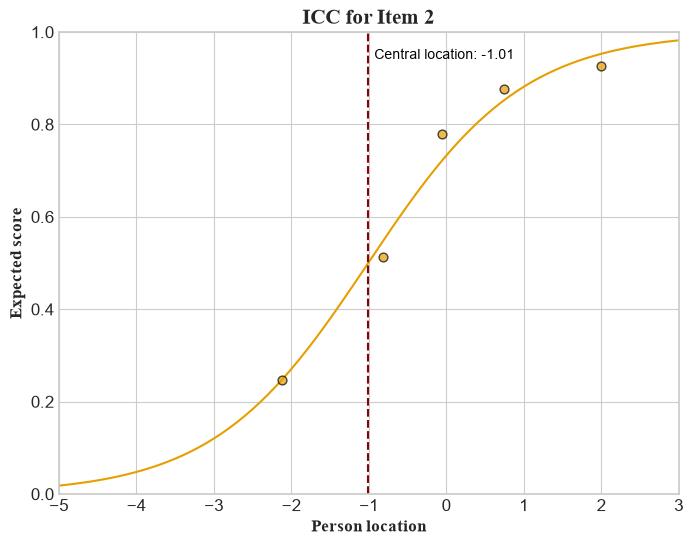

In [22]:
slm.icc('Item_2', title='ICC for Item 2', obs=True, thresh_line=True, xmin=-5, xmax=3, filename='my_slm_icc')

Produce an item information function curve for Item 2

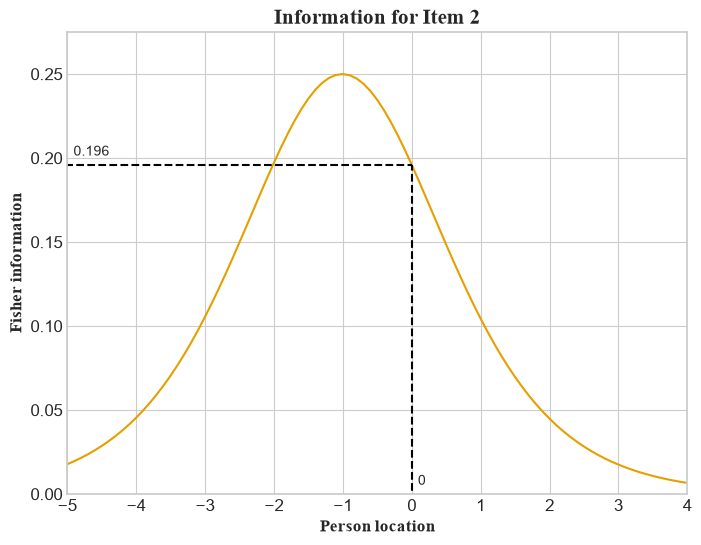

In [23]:
slm.iic('Item_2', point_info_lines=[0], point_info_labels=True, title='Information for Item 2',
        xmin=-5, xmax=4, filename='my_slm_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 10 and 15 plotted.

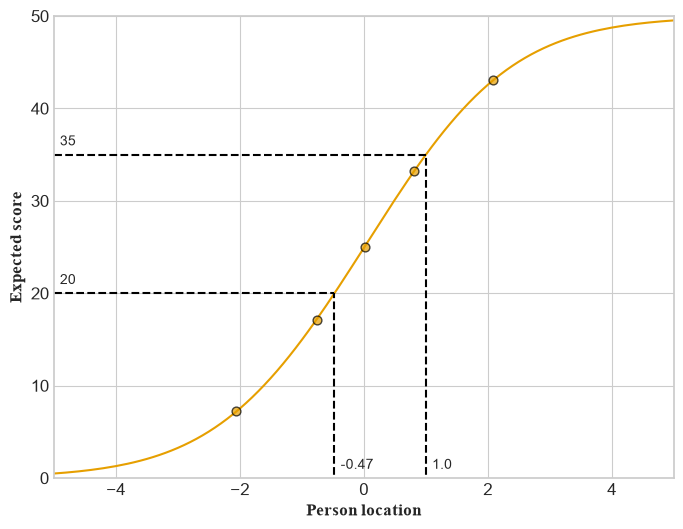

In [24]:
slm.tcc(score_lines=[20, 35], obs=True, score_labels=True, filename='my_slm_tcc')

Produce a test information curve

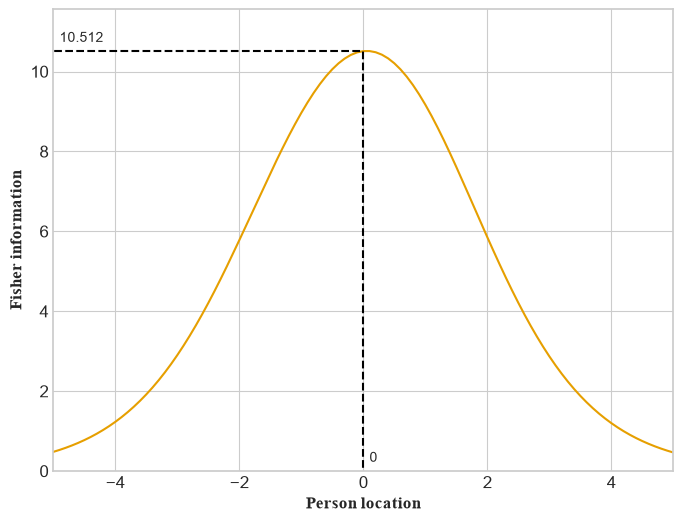

In [25]:
slm.test_info(point_info_lines=[0], point_info_labels=True, filename='my_slm_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

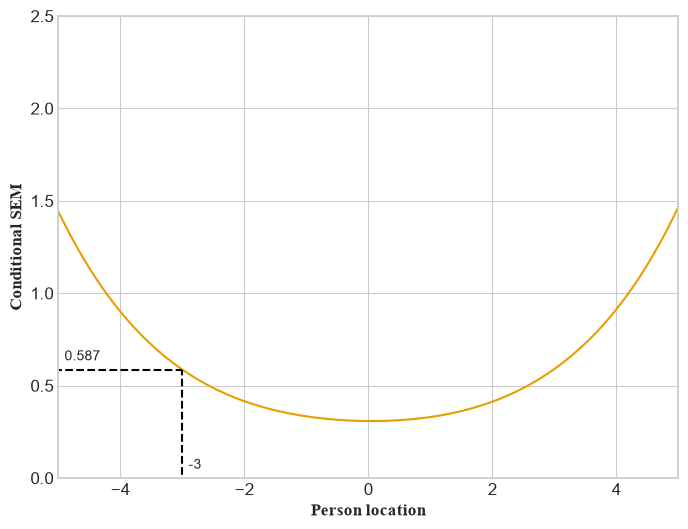

In [26]:
slm.test_csem(point_csem_lines=[-3], point_csem_labels=True, ymax=2.5, filename='my_slm_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

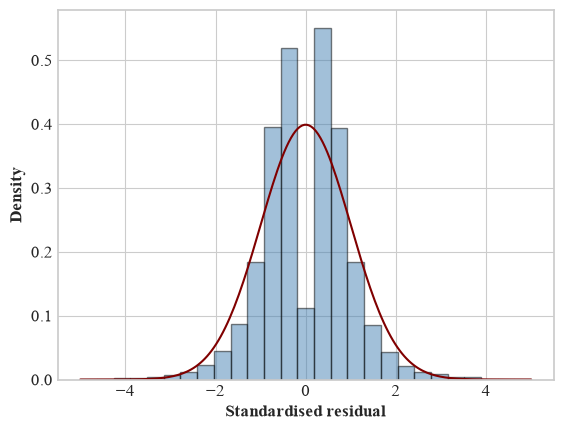

In [27]:
slm.std_residuals_plot(bin_width=0.6, normal=True, filename='my_slm_std_residuals_plot')

Produce a Wright map, showing the person location distribution alongside item names listed by location (Winsteps-style), with mean/±1SD/±2SD reference marks for both

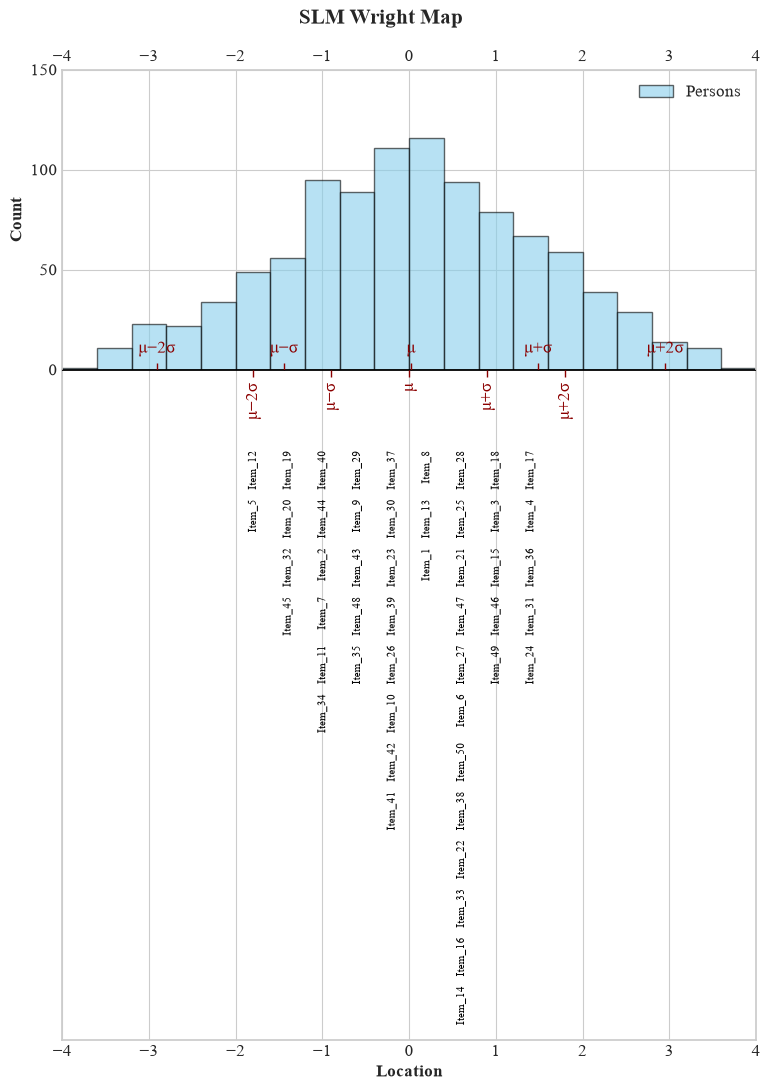

In [28]:
slm.wright_map(item_labels=True, distribution_markers=True, title='SLM Wright Map', filename='my_slm_wright_map')